In [1]:
%load_ext autoreload
%autoreload 2

In [100]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import SpectrumVariationScaler
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1]
)

features.shape

100%|██████████| 1100/1100 [03:50<00:00,  4.77it/s]


(1100, 283, 7)

In [5]:
cnn_train_data = features.transpose(0, 2,1)
cnn_train_data.shape

(1100, 7, 283)

In [ ]:
trainer = SValuesCNNTrainer(
    Path("../models/s_values_cnn"),
    device=torch.device("mps"),
    in_channels=cnn_train_data.shape[1],
    num_channels=283,
    train_multiplier=1e3,
)

res = trainer.train(cnn_train_data, train_labels, n_splits=5, return_predictions=True)

if res is not None:
    spectrum, sigma, (val_rmse, val_gll, val_loss, train_loss) = res # type: ignore

Force retrain enabled. Clearing existing models.


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

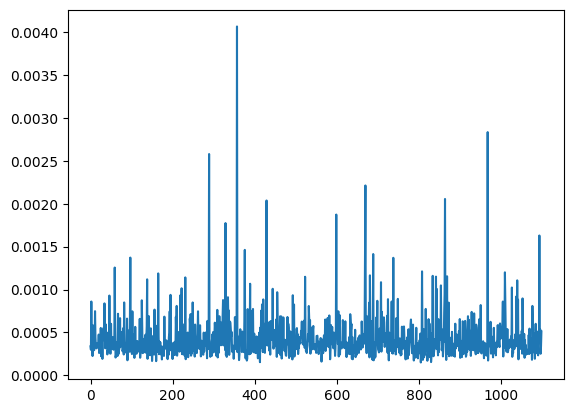

In [8]:
plt.plot(sigma[:, 0])

In [9]:
sigma.min()

np.float64(0.00015011786308605224)

In [13]:
df = pd.DataFrame({
    "rmse": np.mean((spectrum - train_labels) ** 2, axis=1) ** 0.5,
    "sigma": sigma[:, 0]
})

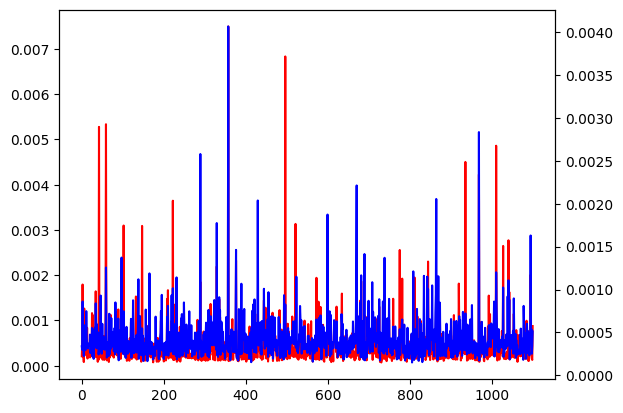

In [16]:
# Plot both rmse and sigma on the same graph with different y-axis

fig, ax1 = plt.subplots()
x = np.arange(len(df))
ax1.plot(x, df['rmse'], color='red')

ax2 = ax1.twinx()
ax2.plot(df['sigma'], color='blue')
plt.show()

In [18]:
df['sigma'] ** 2

0       1.144289e-07
1       8.887890e-08
2       7.400062e-07
3       9.881408e-08
4       1.431135e-07
            ...     
1095    2.323695e-07
1096    2.888068e-07
1097    6.329217e-08
1098    1.154055e-07
1099    2.617029e-07
Name: sigma, Length: 1100, dtype: float64

In [19]:
df['rmse'] ** 2

0       4.291287e-08
1       2.573719e-07
2       3.216332e-06
3       5.939841e-07
4       5.512445e-08
            ...     
1095    1.699469e-07
1096    6.200417e-08
1097    2.414225e-08
1098    1.625167e-08
1099    7.657368e-07
Name: rmse, Length: 1100, dtype: float64

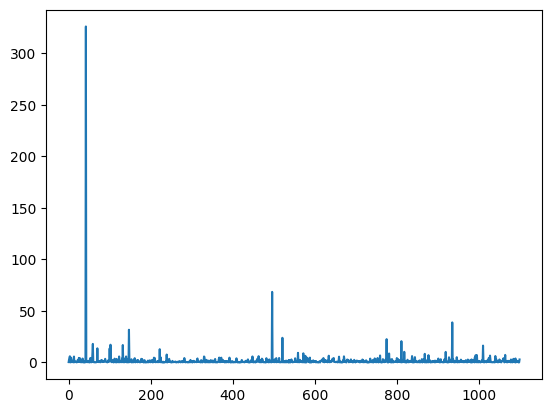

In [20]:
plt.plot(df['rmse'] ** 2 / df['sigma'] ** 2)

In [21]:
(df['rmse'] ** 2 / df['sigma'] ** 2).mean()

np.float64(1.7325690272560172)

{'whiskers': [<matplotlib.lines.Line2D at 0x403768ac0>,
 'caps': [<matplotlib.lines.Line2D at 0x403768fa0>,
 'boxes': [<matplotlib.lines.Line2D at 0x4037687c0>],
 'medians': [<matplotlib.lines.Line2D at 0x4037695d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x4037698d0>],
 'means': []}

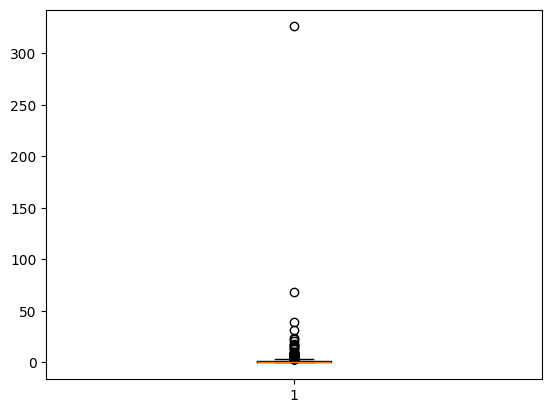

In [23]:
plt.boxplot((df['rmse'] ** 2 / df['sigma'] ** 2))

{'whiskers': [<matplotlib.lines.Line2D at 0x40384eef0>,
 'caps': [<matplotlib.lines.Line2D at 0x4039c6080>,
 'boxes': [<matplotlib.lines.Line2D at 0x40384e290>],
 'medians': [<matplotlib.lines.Line2D at 0x4039c4190>],
 'fliers': [<matplotlib.lines.Line2D at 0x4039c6200>],
 'means': []}

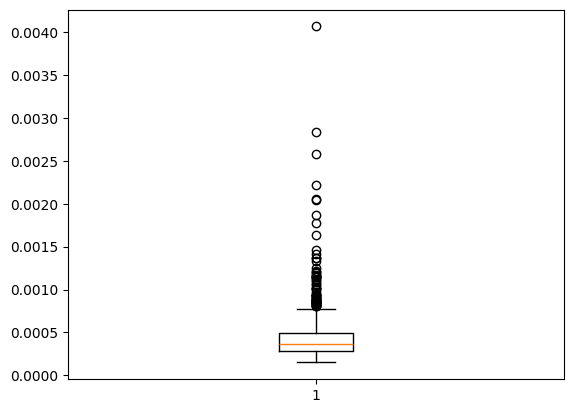

In [36]:
plt.boxplot(df['sigma'])

In [ ]:
df['score'] = df['rmse'] ** 2 / df['sigma'] ** 2

In [32]:
(np.argsort(df['sigma']) + 1) / df['sigma'].shape[0] * 100

0       73.272727
1       37.636364
2       75.545455
3       51.272727
4       14.636364
          ...    
1095    78.636364
1096    61.000000
1097    26.363636
1098    88.090909
1099    32.545455
Name: sigma, Length: 1100, dtype: float64

In [33]:
df['sigma_percentile'] = (np.argsort(df['sigma']) + 1) / df['sigma'].shape[0] * 100

In [34]:
df.sort_values('score', ascending=False)

,rmse,sigma,score,sigma_percentile
42,0.005277,0.000292,326.169719,9.818182
496,0.006834,0.000826,68.513140,29.090909
935,0.004502,0.000722,38.905580,90.272727
147,0.003088,0.000548,31.779289,99.818182
521,0.003133,0.000640,23.969835,71.454545
...,...,...,...,...
862,0.000160,0.000731,0.047587,81.727273
589,0.000120,0.000565,0.045000,46.545455
396,0.000162,0.000774,0.043753,18.000000
439,0.000129,0.000633,0.041656,88.363636


In [27]:
train_data[42].shape

(1406, 283)

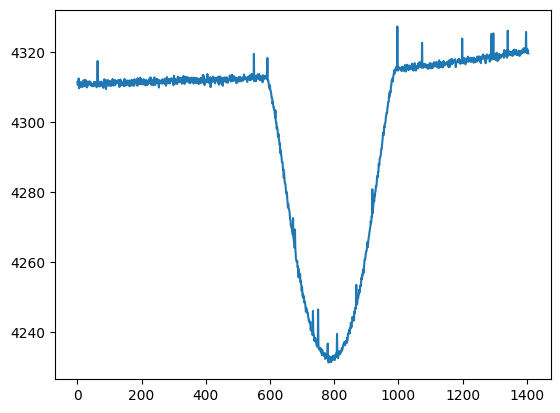

In [35]:
plt.plot(train_data[147].mean(axis=1))

In [37]:
df.corr()

,rmse,sigma,score,sigma_percentile
rmse,1.000000,0.625236,0.465588,-0.017234
sigma,0.625236,1.000000,0.019844,-0.021767
score,0.465588,0.019844,1.000000,-0.033621
sigma_percentile,-0.017234,-0.021767,-0.033621,1.000000


<Axes: xlabel='rmse', ylabel='sigma'>

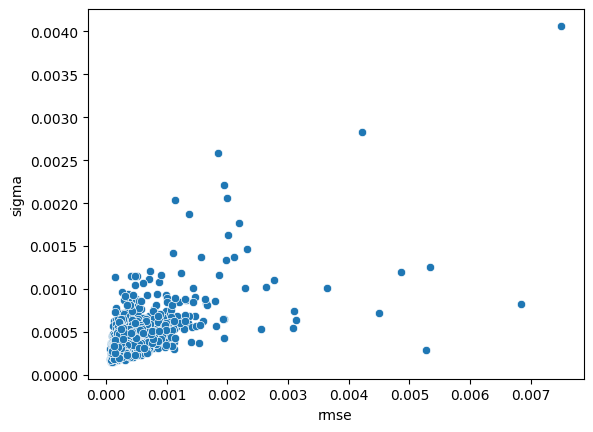

In [38]:
import seaborn as sns

sns.scatterplot(df, x='rmse', y='sigma')

In [42]:
spectrum.std(axis=1) / spectrum.std(axis=1).mean()

array([0.76231704, 0.65971073, 1.27539955, ..., 0.60947286, 0.38579725,
       0.95572634], shape=(1100,))

In [41]:
constant_sigma = 0.000715
scaled_constant_sigma = np.average([constant_sigma] * train_data.shape[0], weights=spectrum.std(axis=1))
scaled_constant_sigma

np.float64(0.0007150000000000001)

In [45]:
spectrum.std(axis=1) * 10

array([0.00171494, 0.00148411, 0.00286919, ..., 0.00137109, 0.0008679 ,
       0.00215004], shape=(1100,))

In [47]:
np.repeat((spectrum.std(axis=1) * 10)[:, np.newaxis], 283, axis=1)

array([[0.00171494, 0.00171494, 0.00171494, ..., 0.00171494, 0.00171494,
        0.00171494],
       [0.00148411, 0.00148411, 0.00148411, ..., 0.00148411, 0.00148411,
        0.00148411],
       [0.00286919, 0.00286919, 0.00286919, ..., 0.00286919, 0.00286919,
        0.00286919],
       ...,
       [0.00137109, 0.00137109, 0.00137109, ..., 0.00137109, 0.00137109,
        0.00137109],
       [0.0008679 , 0.0008679 , 0.0008679 , ..., 0.0008679 , 0.0008679 ,
        0.0008679 ],
       [0.00215004, 0.00215004, 0.00215004, ..., 0.00215004, 0.00215004,
        0.00215004]], shape=(1100, 283))

In [57]:
gll(
    np.concatenate([spectrum, np.repeat((spectrum.std(axis=1) * 2.5)[:, np.newaxis], 283, axis=1)], axis=1),
    train_labels
)

0.37082399286003137

In [71]:
def cost_function(params):
    scale = params[0]
    return - gll(
        np.concatenate([spectrum, np.repeat((spectrum.std(axis=1) * scale)[:, np.newaxis], 283, axis=1)], axis=1),
        train_labels
    )

r = minimize(cost_function, x0=[2.98], method='Nelder-Mead')
r.x, -r.fun

(array([3.02445264]), np.float64(0.3762284889359249))

In [94]:
spectrum.std(axis=1).mean() / 0.0006793903756842543

np.float64(0.33112582781456956)

In [96]:
0.0006793903756842543 / spectrum.std(axis=1).mean()

np.float64(3.02)

In [95]:
(spectrum.std(axis=1) *3.02).mean()

np.float64(0.0006793903756842543)

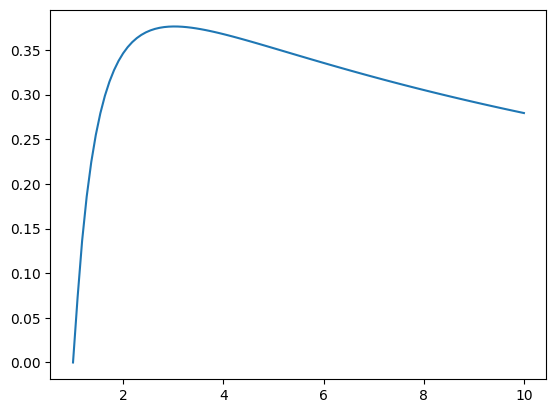

In [68]:
x = np.linspace(1, 10, num=100)
y = [-cost_function([v]) for v in x]
plt.plot(x, y)

In [69]:
np.argmax(y)

np.int64(22)

In [70]:
1 + 22 * (10.0 - 1.0) / 100

2.98

In [72]:
gll(
    np.concatenate([spectrum, np.repeat((spectrum.std(axis=1) * 2.5)[:, np.newaxis], 283, axis=1)], axis=1),
    train_labels
)

0.37082399286003137

In [82]:
gll(
    np.concatenate([features.mean(axis=2), np.repeat((features.mean(axis=2).std(axis=1) * 20)[:, np.newaxis], 283, axis=1)], axis=1),
    train_labels
)

0.21350644312988176

In [83]:
features.mean(axis=2).std(axis=1) * 15

array([0.00268429, 0.00181582, 0.00422705, ..., 0.0013625 , 0.00089246,
       0.00232746], shape=(1100,))

In [86]:
def cost_function_features(params):
    scale = params[0]
    return -gll(
        np.concatenate([features.mean(axis=2), np.repeat((features.mean(axis=2).std(axis=1) * scale)[:, np.newaxis], 283, axis=1)], axis=1),
        train_labels
    )

r = minimize(cost_function_features, x0=[10.0], method='Nelder-Mead')
r.x, -r.fun

(array([6.56726074]), np.float64(0.30076460999659443))

In [97]:
np.mean((spectrum - train_labels)**2)**0.5

np.float64(0.0007257241974924333)

In [ ]:
np.mean((features.mean(axis=2) - train_labels)**2)**0.5

np.float64(1.8895919458206738)

In [101]:
sigma_calculator = SpectrumVariationScaler(mean_sigma=0.00068, num_channels=283)
predicted_sigma = sigma_calculator.get_sigma(spectrum)
predicted_sigma.shape

(1100, 283)

In [104]:
gll(
    np.concatenate([spectrum, predicted_sigma], axis=1),
    train_labels
)

0.37622844545268574